In [11]:
# === SETUP INICIAL ===
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caminhos do projeto
PROJ = Path.cwd().resolve().parent
DATA_DIR = PROJ / "data" / "interim"

# Nome do arquivo que você gerou (ajuste conforme seu caso)
csv_file = DATA_DIR / "bahrain_grand_prix_2022-2024_all_laps.csv"

# Carrega o dataset
df = pd.read_csv(csv_file)
df = df[df["IsInOrOutLap"] == 0]

# Mostra informações básicas do dataset
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 3005 entries, 0 to 3309
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Time                3005 non-null   object 
 1   Driver              3005 non-null   object 
 2   DriverNumber        3005 non-null   int64  
 3   LapTime             3000 non-null   object 
 4   LapNumber           3005 non-null   float64
 5   Stint               3005 non-null   float64
 6   PitOutTime          0 non-null      object 
 7   PitInTime           0 non-null      object 
 8   Sector1Time         2943 non-null   object 
 9   Sector2Time         3002 non-null   object 
 10  Sector3Time         3002 non-null   object 
 11  Sector1SessionTime  2936 non-null   object 
 12  Sector2SessionTime  3002 non-null   object 
 13  Sector3SessionTime  3002 non-null   object 
 14  SpeedI1             2257 non-null   float64
 15  SpeedI2             3002 non-null   float64
 16  SpeedFL    

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Sector3TimeSec,Year,EventName,Session,AirTemp,TrackTemp,Humidity,Pressure,WindSpeed,WindDirection
0,0 days 01:04:22.740000,ALB,23,0 days 00:01:47.636000,1.0,1.0,NaN,NaN,NaN,0 days 00:00:46.031000,...,24.844,2022,Bahrain Grand Prix,Race,23.9,29.0,26.0,1010.4,0.3,13
1,0 days 01:06:03.288000,ALB,23,0 days 00:01:40.548000,2.0,1.0,NaN,NaN,0 days 00:00:32.027000,0 days 00:00:43.725000,...,24.796,2022,Bahrain Grand Prix,Race,23.8,29.0,26.0,1010.4,0.5,357
2,0 days 01:07:43.952000,ALB,23,0 days 00:01:40.664000,3.0,1.0,NaN,NaN,0 days 00:00:32.056000,0 days 00:00:43.928000,...,24.680,2022,Bahrain Grand Prix,Race,23.8,28.8,29.0,1010.2,0.4,13
3,0 days 01:09:25.078000,ALB,23,0 days 00:01:41.126000,4.0,1.0,NaN,NaN,0 days 00:00:32.050000,0 days 00:00:44.161000,...,24.915,2022,Bahrain Grand Prix,Race,23.8,28.7,31.0,1010.4,0.3,50
4,0 days 01:11:07.381000,ALB,23,0 days 00:01:42.303000,5.0,1.0,NaN,NaN,0 days 00:00:32.792000,0 days 00:00:44.560000,...,24.951,2022,Bahrain Grand Prix,Race,23.7,28.3,33.0,1010.4,0.2,314


In [12]:
# Lista das colunas para revisar quais features temos
df.columns.to_list()

# Contagem de linhas, valores nulos e tipos de dados
df.describe(include="all").transpose()

# Percentual de nulos por coluna
(df.isna().mean() * 100).sort_values(ascending=False)


PitOutTime            100.000000
PitInTime             100.000000
DeletedReason          98.668885
SpeedI1                24.891847
SpeedST                14.808652
Sector1SessionTime      2.296173
Sector1Time             2.063228
Sector1TimeSec          2.063228
LapTimeSec              0.166389
LapTime                 0.166389
LapStartDate            0.099834
Sector2SessionTime      0.099834
Sector2Time             0.099834
Sector3SessionTime      0.099834
Sector3Time             0.099834
Sector3TimeSec          0.099834
Sector2TimeSec          0.099834
IsPersonalBest          0.099834
SpeedI2                 0.099834
SpeedFL                 0.099834
Position                0.099834
Stint                   0.000000
Time                    0.000000
DriverNumber            0.000000
Driver                  0.000000
LapNumber               0.000000
LapStartTime            0.000000
Team                    0.000000
FreshTyre               0.000000
TyreLife                0.000000
Compound  

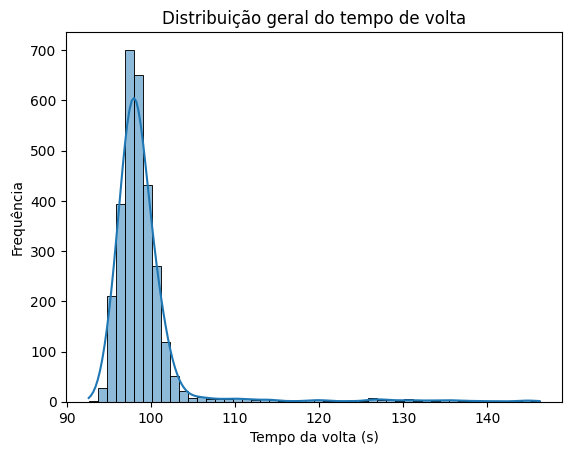

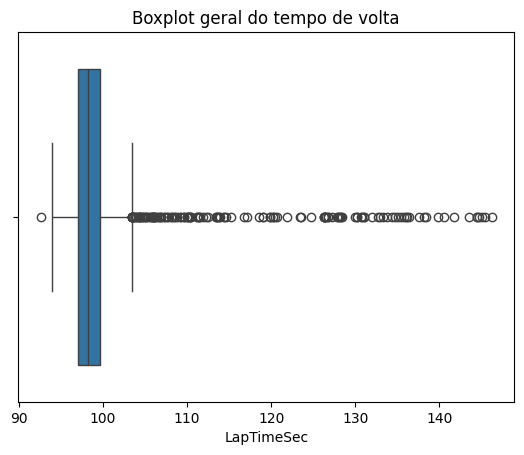

In [13]:
# Distribuição dos tempos de volta em segundos (ignora NaN)
sns.histplot(df["LapTimeSec"].dropna(), bins=50, kde=True)
plt.title("Distribuição geral do tempo de volta")
plt.xlabel("Tempo da volta (s)")
plt.ylabel("Frequência")
plt.show()

# Boxplot geral de tempos de volta
sns.boxplot(x=df["LapTimeSec"])
plt.title("Boxplot geral do tempo de volta")
plt.show()


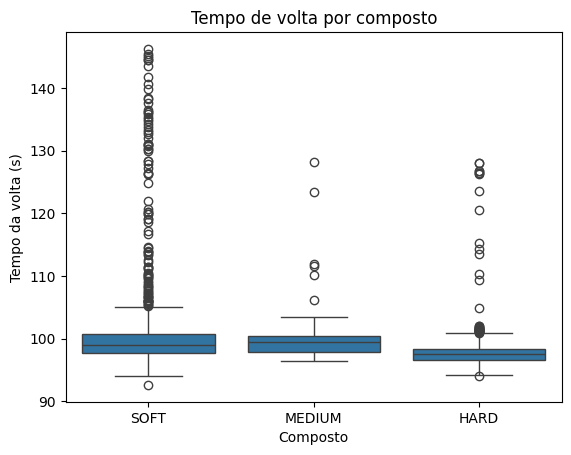

In [14]:
# Boxplot dos tempos de volta por composto
if "Compound" in df.columns:
    sns.boxplot(data=df, x="Compound", y="LapTimeSec", order=["SOFT","MEDIUM","HARD"])
    plt.title("Tempo de volta por composto")
    plt.xlabel("Composto")
    plt.ylabel("Tempo da volta (s)")
    plt.show()

# Estatísticas resumidas por composto
if "Compound" in df.columns:
    df.groupby("Compound")["LapTimeSec"].describe().round(2)


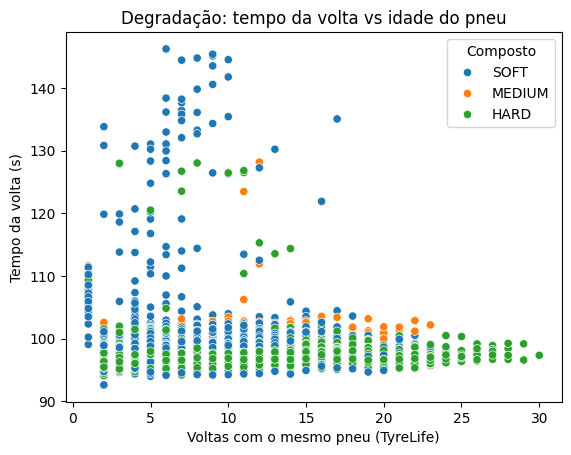

In [15]:
# Relação entre idade do pneu e tempo de volta
if "TyreLife" in df.columns:
    sns.scatterplot(data=df, x="TyreLife", y="LapTimeSec", hue="Compound")
    plt.title("Degradação: tempo da volta vs idade do pneu")
    plt.xlabel("Voltas com o mesmo pneu (TyreLife)")
    plt.ylabel("Tempo da volta (s)")
    plt.legend(title="Composto")
    plt.show()


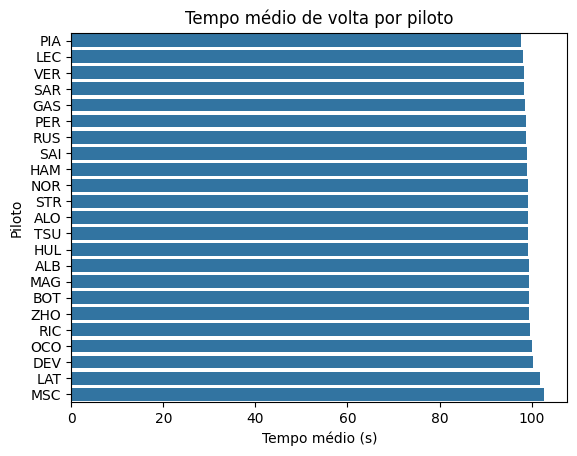

In [16]:
# Tempo médio de volta por piloto
df.groupby("Driver")["LapTimeSec"].mean().sort_values()

# Gráfico de barras com tempo médio
sns.barplot(
    y=df.groupby("Driver")["LapTimeSec"].mean().sort_values().index,
    x=df.groupby("Driver")["LapTimeSec"].mean().sort_values().values
)
plt.title("Tempo médio de volta por piloto")
plt.xlabel("Tempo médio (s)")
plt.ylabel("Piloto")
plt.show()


In [17]:
# Diferença média de tempo entre volta normal e volta pós-pit (PitOutLap)
if "IsPitOutLap" in df.columns:
    pit_out = df[df["IsPitOutLap"] == 1]["LapTimeSec"]
    clean = df[df["IsInOrOutLap"] == 0]["LapTimeSec"]

    print(f"Tempo médio de volta normal: {clean.mean():.2f}s")
    print(f"Tempo médio de volta de saída de pit: {pit_out.mean():.2f}s")


Tempo médio de volta normal: 99.18s
Tempo médio de volta de saída de pit: nans


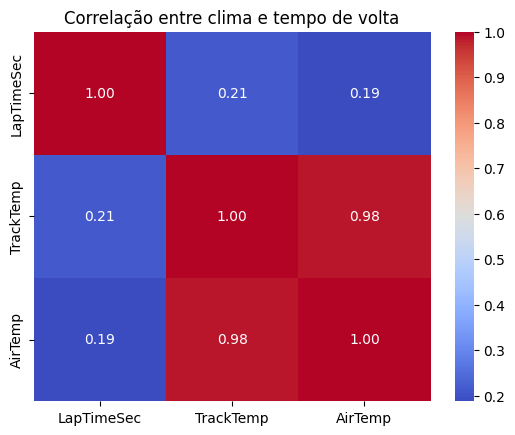

In [18]:
# Correlação entre temperatura de pista/ar e tempo de volta
if "TrackTemp" in df.columns and "LapTimeSec" in df.columns:
    corr = df[["LapTimeSec", "TrackTemp", "AirTemp"]].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlação entre clima e tempo de volta")
    plt.show()
